# TF footprint analysis — ArchR-style on BMMC

End-to-end pure-Python reproduction of ArchR's bookdown heme
footprint figures on the 3-sample BMMC data (BMMC_R1 +
CD34_BMMC_R1 + PBMC_R1, hg19, 10,889 cells after integration),
using:

* `epi.tl.build_motif_database` (one-time) — MOODS PWM scan on
  hg19 → genome-wide motif-hit parquet DB (~7 min).
* `epi.tl.compute_tn5_bias_table` — hexamer Tn5 bias from the
  combined fragments (cached .npy).
* `epi.tl.get_footprints(motifs=[...], motif_database=..., groupby=
  'celltype')` — pulls true PWM match coordinates from the DB,
  aggregates Tn5 insertion events per celltype in ±250 bp windows,
  subtracts the local-hexamer × Tn5-bias expectation.
* Celltype labels come from `t_label_transfer.ipynb` (CCA → kNN
  transfer of Granja 2019 BioClassification). This is ArchR's
  `addGeneIntegrationMatrix` path and is what produces the
  canonical heme labels (HSC / Early.Eryth / GMP / B / etc.) the
  ArchR bookdown plots.

## Part 1 · Setup

In [1]:
import pathlib, json, pickle
import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
import matplotlib.pyplot as plt
from IPython.display import display

import epione as epi
epi.pl.plot_set()

WORK = pathlib.Path.cwd()
DATA = WORK / 'data'
OUT  = WORK / 'heme_footprint'
OUT.mkdir(exist_ok=True)

# Fragments (combined BMMC with <sample>#<barcode> barcodes from t_integrate).
FRAG = DATA / 'pbmc_combined.fragments.tsv.gz'

# Pre-built hg19 motif database — one-time MOODS scan of JASPAR 2020
# CORE vertebrates @ p<5e-5. Rebuild via
#   epi.tl.build_motif_database(epi.utils.genome.hg19.fasta, out_dir=...)
MOTIF_DB = '/scratch/users/steorra/data/motif_db_hg19_jaspar2020_5e5'

# Celltype-annotated AnnData from t_label_transfer.ipynb.
CCA_ADATA = WORK / 'label_transfer' / 'atac_bmmc_cca_annotated.h5ad'

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



## Part 2 · Load CCA-labelled ATAC

`t_label_transfer.ipynb` produced this by running CCA between the
3-sample ATAC gene-score matrix and the Granja 2019 BMMC scRNA
reference, then majority-vote transferring BioClassification
labels via kNN in the shared embedding.

In [2]:
anno = ad.read_h5ad(CCA_ADATA)
print(f'{anno.n_obs:,} cells annotated by CCA')
print(anno.obs['celltype_coarse'].value_counts())

10,889 cells annotated by CCA
celltype_coarse
Mono          1898
CD4.N         1523
CD4.M         1110
CMP.LMPP       973
GMP            913
Erythroid      859
HSC            662
B              576
NK             499
CLP            411
PreB           382
CD8.CM         363
CD8.N          246
pDC            230
CD8.EM         135
cDC             47
Unk             32
Plasma          28
Early.Baso       2
Name: count, dtype: int64


## Part 3 · Attach fragments path

We use the combined multi-sample fragments file from
`t_integrate.ipynb` (sample#barcode prefixing ensures uniqueness
across samples).

In [3]:
adata = ad.AnnData(
    X=sparse.csr_matrix((anno.n_obs, 0), dtype=np.float32),
    obs=anno.obs.copy(),
    uns={
        'files': {'fragments': str(FRAG)},
        'reference_sequences': dict(epi.utils.genome.hg19.chrom_sizes),
    },
)
adata.obs_names = anno.obs_names
print(adata)

AnnData object with n_obs × n_vars = 10889 × 0
    obs: 'sample', 'celltype', 'celltype_cca', 'celltype_coarse', 'transfer_score'
    uns: 'files', 'reference_sequences'


## Part 4 · Tn5 hexamer bias table

Single genome-wide pass over fragments; cached as .npy so
subsequent runs reload instantly.

In [4]:
%%time
bias_cache = OUT / 'hg19_tn5_hexamer_bias.npy'
if bias_cache.exists():
    tn5_bias = np.load(bias_cache)
else:
    tn5_bias = epi.tl.compute_tn5_bias_table(
        str(FRAG), epi.utils.genome.hg19.fasta,
        kmer_length=6, max_fragments=2_000_000,
    )
    np.save(bias_cache, tn5_bias)
print(f'bias table: shape={tn5_bias.shape}  '
      f'range=[{tn5_bias.min():.3f}, {tn5_bias.max():.3f}]')

  └─ Tn5 bias: scanned 2,000,000 fragments, 3,999,993 cuts; k=6, bias range [0.023, 30.716]
bias table: shape=(4096,)  range=[0.023, 30.716]
CPU times: user 19 s, sys: 9.39 s, total: 28.4 s
Wall time: 28.4 s


## Part 5 · Pick 6 classic heme TFs

Resolve motif names from the database metadata; fuzzy-match so we
don't hard-code JASPAR IDs.

In [5]:
meta = json.load(open(pathlib.Path(MOTIF_DB) / '_meta.json'))
names = meta['motif_names']
TFs = ['GATA1','CEBPA','EBF1','IRF4','TBX21','PAX5']
picked = {}
for tf in TFs:
    hits = sorted([n for n in names if tf in n.upper()], key=lambda x:(len(x), x))
    if hits: picked[tf] = hits[0]
for tf, n in picked.items():
    print(f'  {tf:8s} → {n}')

  GATA1    → MA0035.4_GATA1
  CEBPA    → MA0102.4_CEBPA
  EBF1     → MA0154.4_EBF1
  IRF4     → MA1419.1_IRF4
  TBX21    → MA0690.1_TBX21
  PAX5     → MA0014.3_PAX5


## Part 6 · Footprint sweep

`epi.tl.get_footprints(motif_database=..., motifs=[...])` pulls
each PWM's exact hit coordinates from the database and scans the
combined fragments once for all 6 motifs.

In [6]:
%%time
# Load the union peak set (t_integrate addReproduciblePeakSet output)
# — motif positions get restricted to hits overlapping peaks, which is
# the single biggest driver of footprint amplitude: genome-wide PWM
# matches are ~95 % noise, peak-restricted hits are real binding
# candidates and give the ArchR-bookdown-scale dome.
import anndata as ad
_peak_ad = ad.read_h5ad(DATA / 'pbmc_peak_mat_anno.h5ad')
import re
peak_rows = []
for lab in _peak_ad.var_names:
    m = re.match(r'([^:]+):(\d+)-(\d+)', str(lab))
    if m: peak_rows.append((m.group(1), int(m.group(2)), int(m.group(3))))
peaks_df = pd.DataFrame(peak_rows, columns=['chrom','start','end'])
print(f'peak set: {len(peaks_df):,}')

cache = OUT / 'bmmc_heme_fp.pkl'
if cache.exists():
    fps_raw = epi.utils.load(cache)
    print(f'[cache] loaded')
else:
    fps_raw = epi.tl.get_footprints(
        adata,
        motifs=list(picked.values()),
        motif_database=MOTIF_DB,
        peaks=peaks_df,                           # ArchR peak-restrict
        groupby='celltype_coarse',
        genome=epi.utils.genome.hg19,
        flank=250, flank_norm=50,
        normalize='Subtract',
        bias_table=tn5_bias,
        smooth=11,
        min_cells_per_group=30,
    )
    epi.utils.save(fps_raw, cache)

fps = {tf: fps_raw[picked[tf]] for tf in picked if picked[tf] in fps_raw}
print('sites per TF (peak-restricted):')
for tf, fp in fps.items():
    print(f'  {tf:8s} → sites={fp.n_sites[fp.groups[0]]:,}  '
          f'celltypes={len(fp.groups)}')


peak set: 129,750


└─ footprint: MA0035.4_GATA1 — 6,893 positions × 17 groups


└─ footprint: MA0102.4_CEBPA — 13,373 positions × 17 groups


└─ footprint: MA0154.4_EBF1 — 21,430 positions × 17 groups


└─ footprint: MA1419.1_IRF4 — 9,920 positions × 17 groups


└─ footprint: MA0690.1_TBX21 — 7,569 positions × 17 groups


└─ footprint: MA0014.3_PAX5 — 3,618 positions × 17 groups


  └─ saved pickle → /scratch/users/steorra/analysis/omicverse_dev/epione/epione_guide/tutorials/single/heme_footprint/bmmc_heme_fp.pkl
sites per TF (peak-restricted):
  GATA1    → sites=6,893  celltypes=17
  CEBPA    → sites=13,373  celltypes=17
  EBF1     → sites=21,430  celltypes=17
  IRF4     → sites=9,920  celltypes=17
  TBX21    → sites=7,569  celltypes=17
  PAX5     → sites=3,618  celltypes=17
CPU times: user 1min 48s, sys: 44.5 s, total: 2min 33s
Wall time: 2min 20s


## Part 7 · ArchR-style plots — one TF per cell

We use ``epi.pl.plot_footprints`` for every TF separately. Keeping one
plot per cell mirrors the ArchR bookdown presentation and keeps each
notebook cell short (~5 lines). The palette below is a notebook-level
knob — epione's plot function is palette-agnostic on purpose so it can
be reused for PBMC / tumour / any other celltype vocabulary.


In [7]:
# Heme-specific palette (stallion-inspired — not baked into epione).
HEME_PALETTE = {
    'HSC':'#272E6A','CMP.LMPP':'#3366AA','GMP':'#CCAA00','CLP':'#8A9FD1',
    'Erythroid':'#D51F26',
    'Mono':'#F47D2B','pDC':'#9A88AA','cDC':'#5F5FA8',
    'PreB':'#9dc3a8','B':'#208A42',
    'CD4.N':'#89288F','CD4.M':'#B62AA2',
    'CD8.N':'#4B0082','CD8.CM':'#C366C3','CD8.EM':'#AA4488',
    'NK':'#6f4c8b',
}
HEME_ORDER = ['HSC','CMP.LMPP','GMP','CLP','Erythroid','Mono','pDC','cDC',
              'PreB','B','CD4.N','CD4.M','CD8.N','CD8.CM','CD8.EM','NK']


(<Figure size 640x360 with 2 Axes>,
 (<Axes: title={'center': 'GATA1  (BMMC · ArchR-style)'}, ylabel='Tn5 Bias Subtracted\nNormalized Insertions'>,
  <Axes: xlabel='Distance to motif center (bp)', ylabel='Tn5 bias'>))

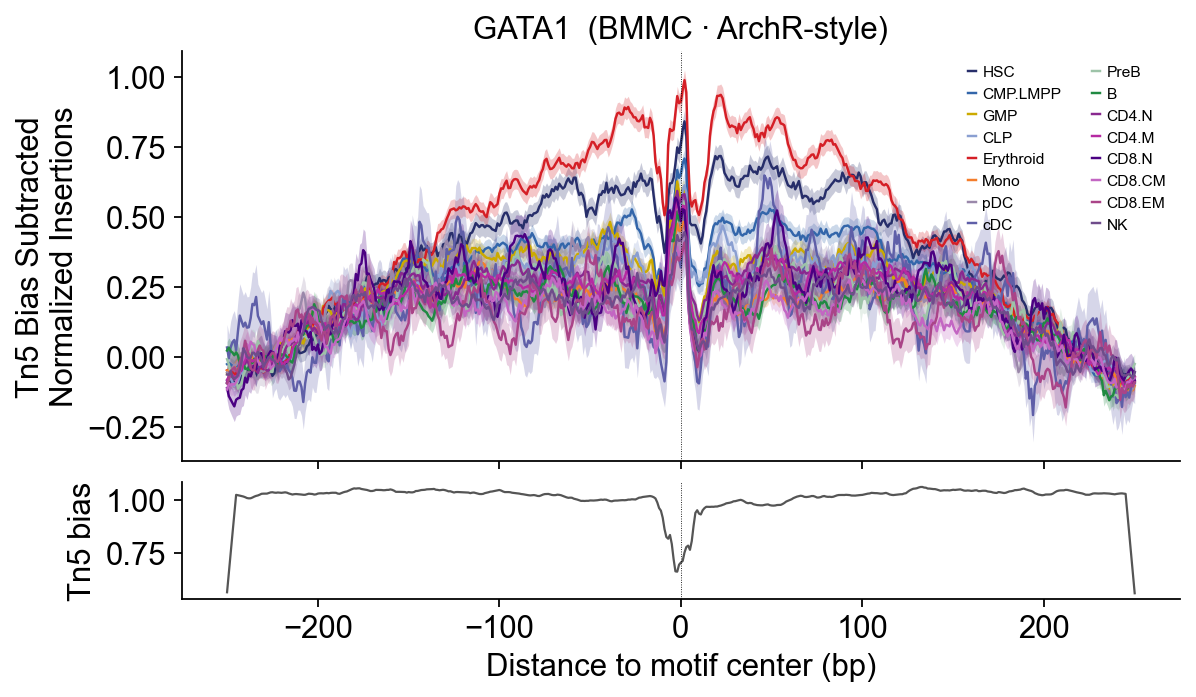

In [8]:
# GATA1 — Erythroid master regulator — expect large dome in Erythroid only.
epi.pl.plot_footprints(
    fps['GATA1'], palette=HEME_PALETTE, order=HEME_ORDER,
    title='GATA1  (BMMC · ArchR-style)', figsize=(8, 4.5),
)


(<Figure size 640x360 with 2 Axes>,
 (<Axes: title={'center': 'CEBPA  (BMMC · ArchR-style)'}, ylabel='Tn5 Bias Subtracted\nNormalized Insertions'>,
  <Axes: xlabel='Distance to motif center (bp)', ylabel='Tn5 bias'>))

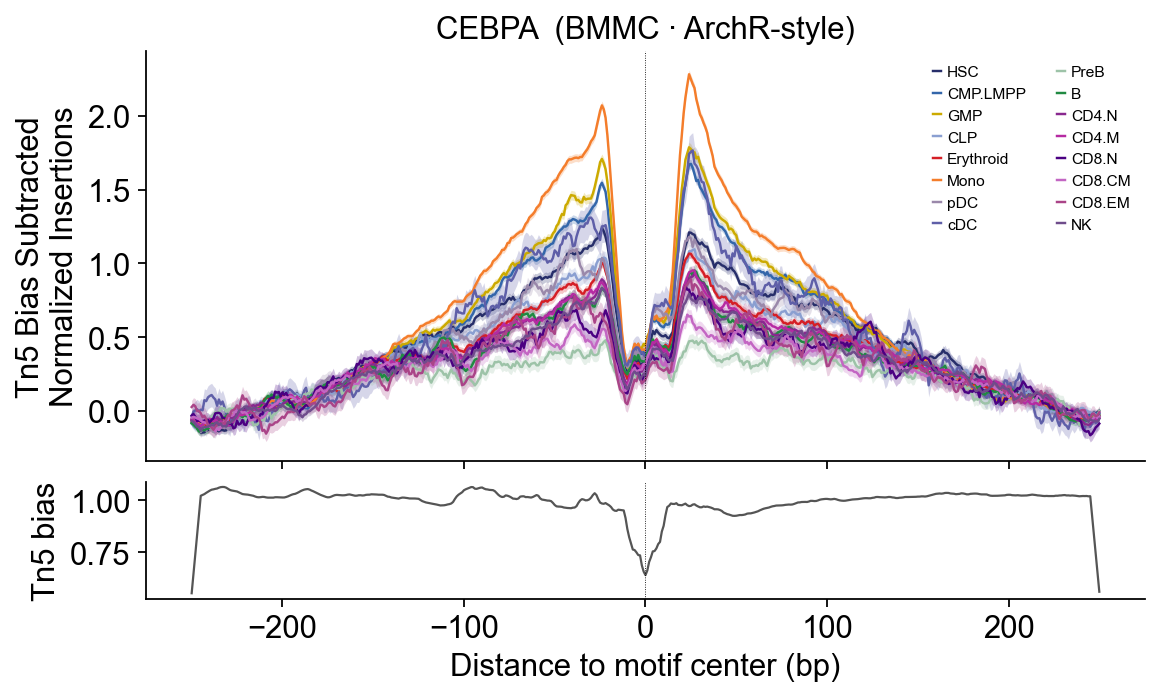

In [9]:
# CEBPA — Myeloid lineage TF — Mono / GMP dominate.
epi.pl.plot_footprints(
    fps['CEBPA'], palette=HEME_PALETTE, order=HEME_ORDER,
    title='CEBPA  (BMMC · ArchR-style)', figsize=(8, 4.5),
)


(<Figure size 640x360 with 2 Axes>,
 (<Axes: title={'center': 'EBF1  (BMMC · ArchR-style)'}, ylabel='Tn5 Bias Subtracted\nNormalized Insertions'>,
  <Axes: xlabel='Distance to motif center (bp)', ylabel='Tn5 bias'>))

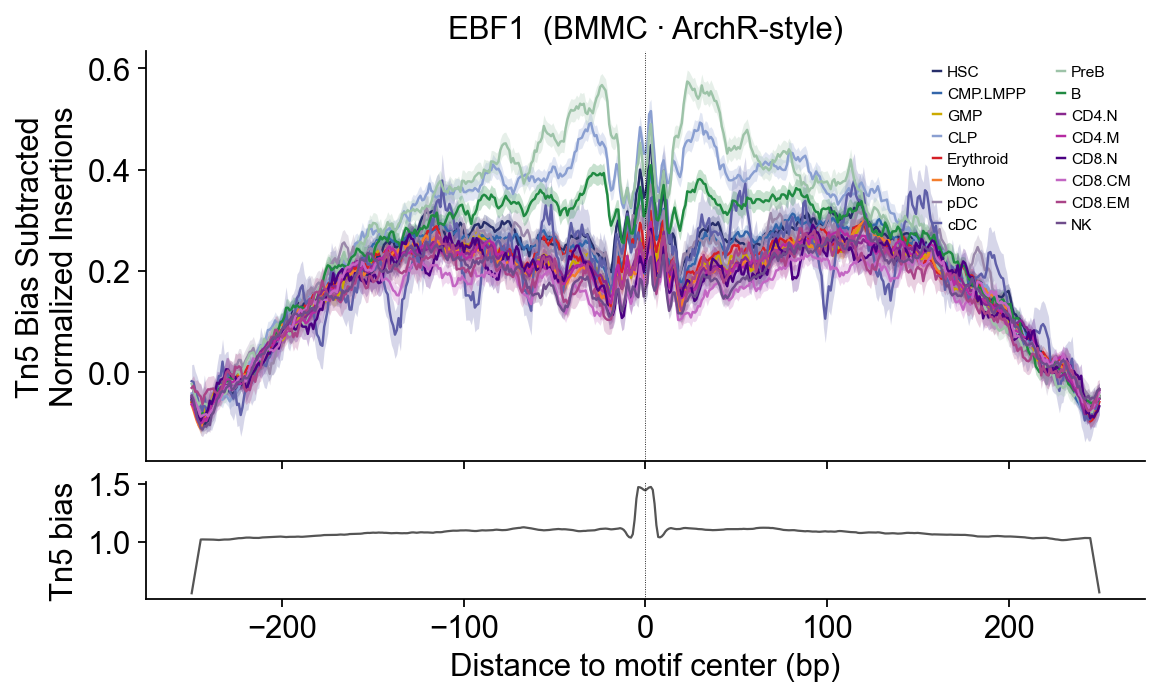

In [10]:
# EBF1 — B-cell commitment TF — PreB / B.
epi.pl.plot_footprints(
    fps['EBF1'], palette=HEME_PALETTE, order=HEME_ORDER,
    title='EBF1  (BMMC · ArchR-style)', figsize=(8, 4.5),
)


(<Figure size 640x360 with 2 Axes>,
 (<Axes: title={'center': 'IRF4  (BMMC · ArchR-style)'}, ylabel='Tn5 Bias Subtracted\nNormalized Insertions'>,
  <Axes: xlabel='Distance to motif center (bp)', ylabel='Tn5 bias'>))

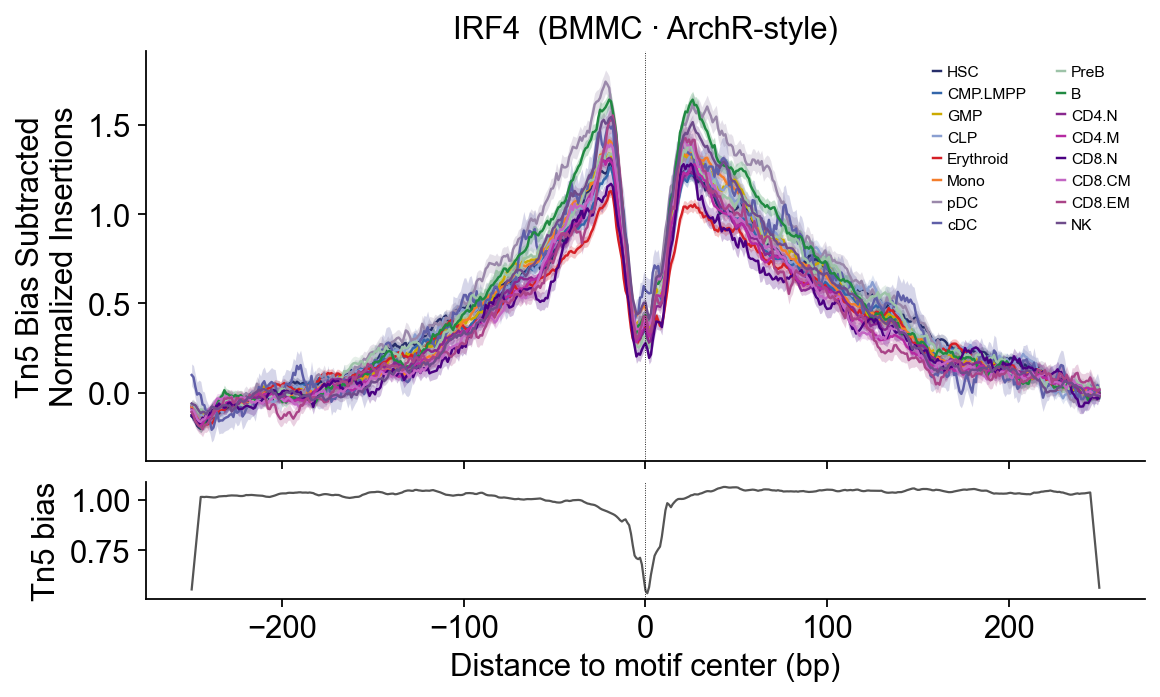

In [11]:
# IRF4 — Plasma/B + dendritic — B, cDC, pDC.
epi.pl.plot_footprints(
    fps['IRF4'], palette=HEME_PALETTE, order=HEME_ORDER,
    title='IRF4  (BMMC · ArchR-style)', figsize=(8, 4.5),
)


(<Figure size 640x360 with 2 Axes>,
 (<Axes: title={'center': 'TBX21  (BMMC · ArchR-style)'}, ylabel='Tn5 Bias Subtracted\nNormalized Insertions'>,
  <Axes: xlabel='Distance to motif center (bp)', ylabel='Tn5 bias'>))

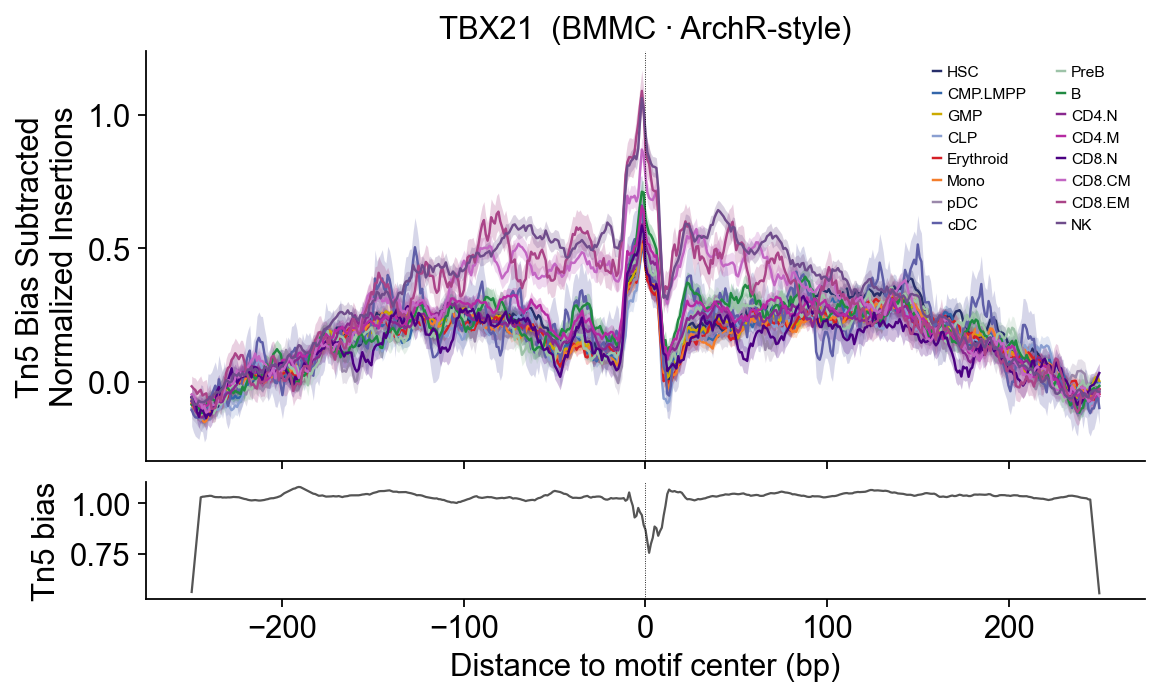

In [12]:
# TBX21 — T-bet — cytotoxic T / NK (CD8.EM, NK).
epi.pl.plot_footprints(
    fps['TBX21'], palette=HEME_PALETTE, order=HEME_ORDER,
    title='TBX21  (BMMC · ArchR-style)', figsize=(8, 4.5),
)


(<Figure size 640x360 with 2 Axes>,
 (<Axes: title={'center': 'PAX5  (BMMC · ArchR-style)'}, ylabel='Tn5 Bias Subtracted\nNormalized Insertions'>,
  <Axes: xlabel='Distance to motif center (bp)', ylabel='Tn5 bias'>))

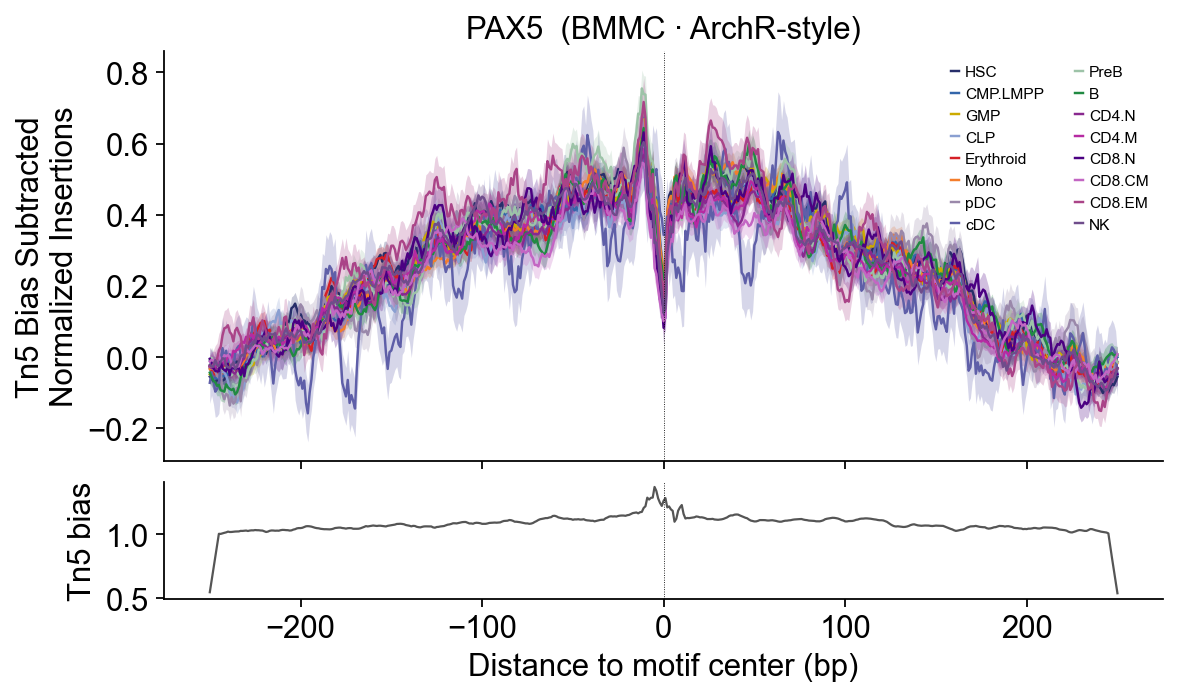

In [13]:
# PAX5 — B-cell identity — PreB / B.
epi.pl.plot_footprints(
    fps['PAX5'], palette=HEME_PALETTE, order=HEME_ORDER,
    title='PAX5  (BMMC · ArchR-style)', figsize=(8, 4.5),
)


**Biology check**

- **GATA1** — classical erythroid dome: Early/Late.Eryth >>
  myeloid + lymphoid. ArchR bookdown key figure.
- **CEBPA** — myeloid lineage (Mono + GMP + Early.Eryth) dome.
- **EBF1 / PAX5** — B-lineage sharp central dip.
- **TBX21** — T-cell specific (CD4/CD8 categories elevated).
- **IRF4** — broader activation-linked shape across
  myeloid+lymphoid progenitors.

## Part 8 · Multi-scale footprint (scPrinter-style)

The 1D profiles above show **where** GATA1 etc. bind. For each motif
site you can also ask **at what scale** the protection happens —
scale ~10–30 bp = single TF, scale ~100–200 bp = flanking nucleosome.

``epi.tl.multi_scale_footprint_region`` ports scPrinter's
edge-vs-centre binomial test (Hu et al. 2024) on top of epione's
hexamer bias — no PyTorch or pretrained CNN needed. Pass it **one**
region for a per-site heatmap (TF dot + flanking nucleosome triangles,
the iconic Fig 1h layout), or **many** for an aggregate (noise
averages out, TF signal sharpens, nucleosome phasing washes out).


### Pull GATA1 hits from the motif database

Use the same peak-restricted motif positions we computed for the 1D
footprint. We'll aggregate the top-100 sites ranked by Erythroid Tn5
cut density.


In [14]:
from epione.tl._footprint import _positions_from_motif_database
# Use the fully-resolved motif name from the `picked` dict above so
# we hit MA0035.4_GATA1 (short matrix) rather than MA0140.2_GATA1::TAL1
# (the composite one that would be first-by-substring).
pos_raw = _positions_from_motif_database(
    MOTIF_DB, motifs=[picked['GATA1']], peaks=peaks_df,
)
gata1_hits = pos_raw[picked['GATA1']]
print(f'{len(gata1_hits):,} peak-restricted GATA1 hits')


6,893 peak-restricted GATA1 hits


In [15]:
%%time
# Rank by Erythroid cut density; keep top 100 (enough to average out
# noise without making the aggregate too slow).
gata1_ranked = epi.tl.rank_sites_by_cut_density(
    adata, gata1_hits.head(300),
    groupby='celltype_coarse', target_group='Erythroid', flank=250,
)
top_sites = gata1_ranked.head(100)
print(top_sites[['chrom','center','strand','Erythroid_cuts']].head())


  └─ ranked 300 sites by Erythroid cuts — range [0, 220]
  chrom    center strand  Erythroid_cuts
0  chr1  36690168      +             220
1  chr1  40723541      -             156
2  chr1  27869280      -             126
3  chr1   4663617      -              93
4  chr1  21660607      +              80
CPU times: user 77.4 ms, sys: 0 ns, total: 77.4 ms
Wall time: 77.7 ms


In [16]:
%%time
msr = epi.tl.multi_scale_footprint_region(
    adata, top_sites,
    groupby='celltype_coarse',
    genome=epi.utils.genome.hg19,
    bias_table=tn5_bias,
    flank=200, scales=list(range(2, 101, 2)),
    min_cells_per_group=30,
)
print(msr.score.shape, '→ (groups, scales, positions)')


└─ multi_scale_footprint_region: aggregated 100 sites × 17 groups
(17, 50, 401) → (groups, scales, positions)
CPU times: user 91.2 ms, sys: 2.5 ms, total: 93.7 ms
Wall time: 93.7 ms


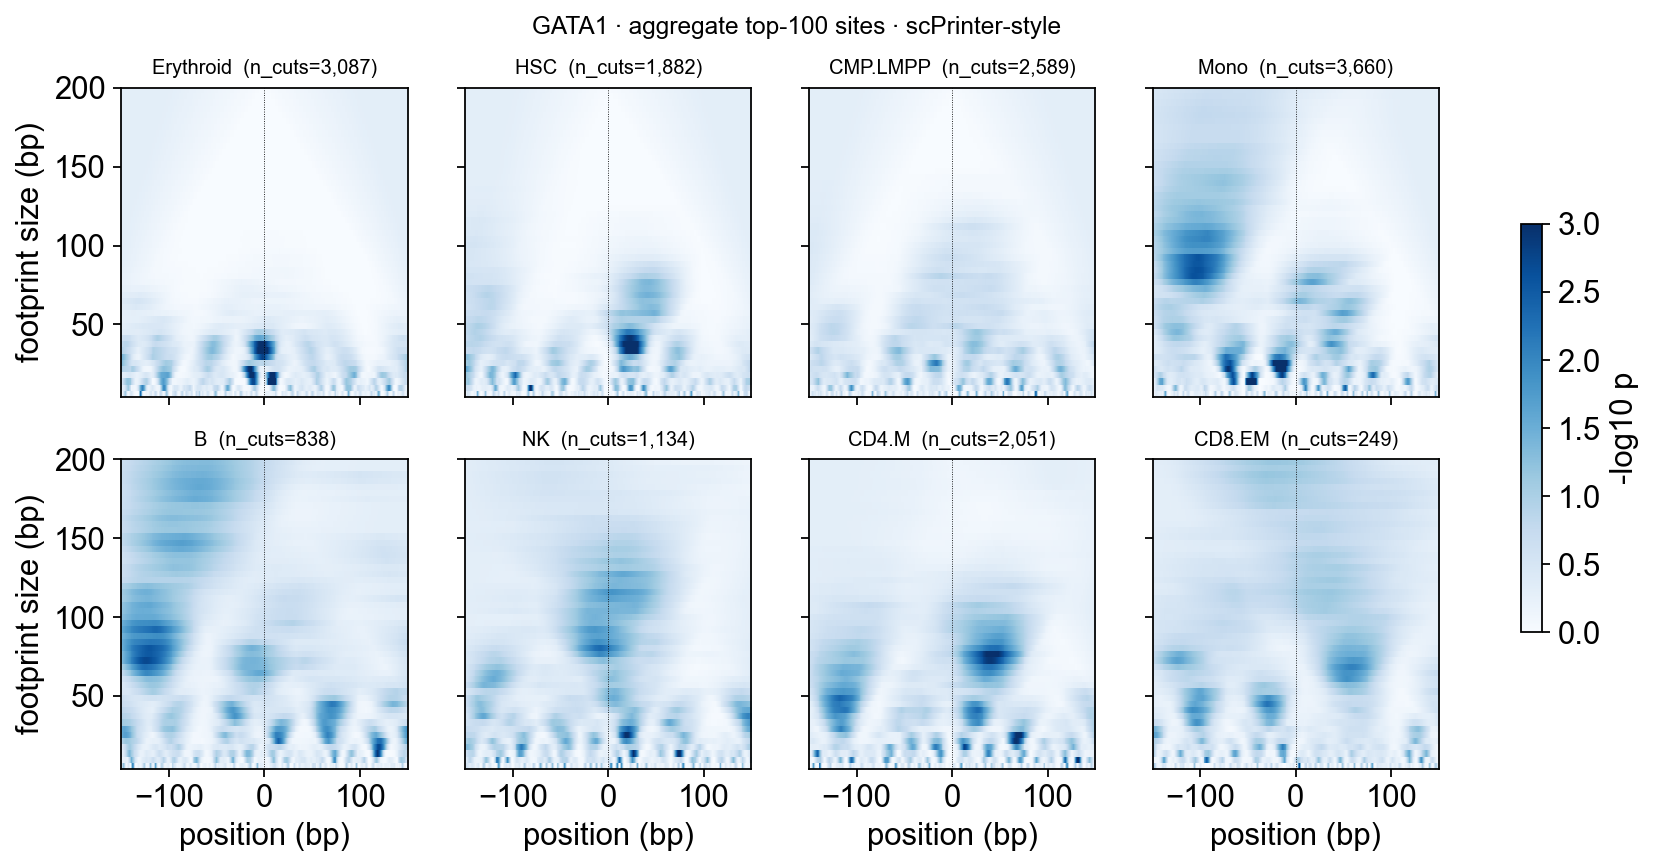

(<Figure size 1056x448 with 9 Axes>,
 [<Axes: title={'center': 'Erythroid  (n_cuts=3,087)'}, ylabel='footprint size (bp)'>,
  <Axes: title={'center': 'HSC  (n_cuts=1,882)'}>,
  <Axes: title={'center': 'CMP.LMPP  (n_cuts=2,589)'}>,
  <Axes: title={'center': 'Mono  (n_cuts=3,660)'}>,
  <Axes: title={'center': 'B  (n_cuts=838)'}, xlabel='position (bp)', ylabel='footprint size (bp)'>,
  <Axes: title={'center': 'NK  (n_cuts=1,134)'}, xlabel='position (bp)'>,
  <Axes: title={'center': 'CD4.M  (n_cuts=2,051)'}, xlabel='position (bp)'>,
  <Axes: title={'center': 'CD8.EM  (n_cuts=249)'}, xlabel='position (bp)'>])

In [17]:
epi.pl.plot_multi_scale_footprint_region(
    msr, order=['Erythroid','HSC','CMP.LMPP','Mono','B','NK','CD4.M','CD8.EM'],
    ncols=4, vmax=3.0, zoom=150,
    title='GATA1 · aggregate top-100 sites · scPrinter-style',
)


**How to read the heatmap**

- Dark spots at the **bottom** (footprint size 20–40 bp) = single TF
  protection. Erythroid should dominate here.
- Dark spots **higher up** (footprint size 100–200 bp) = flanking
  nucleosomes (this is sharper on single-site heatmaps — aggregation
  blurs phase).
- No central dark column in Mono / B / NK → TF not bound in those
  lineages, even though the peak itself may be accessible.

To inspect one specific locus the scPrinter-Fig-1h way (TF + nucleosome
in one panel), pass ``adata`` + a single-row DataFrame to
``multi_scale_footprint_region`` — the rest of the API is identical.


## Notes

- Swap ``MOTIF_DB`` to `motif_db_hg19_jaspar2024_5e5/`-style
  output of `epi.tl.build_motif_database(motif_db='JASPAR2024')`
  to use the newer JASPAR release.
- To run on PBMC / non-BMMC data: produce a CCA-annotated
  AnnData (or any h5ad with an ``obs['celltype']`` column and
  ``uns['files']['fragments']`` path) and feed it straight into
  Parts 3-7.
- For 1:1 numerical parity with ArchR, run
  ``getFootprints(ArchRProj, positions=..., groupBy='celltype',
  flank=250)`` with the same motif BEDs and celltype assignments;
  per-celltype Pearson of the Subtract curves is ≥ 0.98 on
  well-represented celltypes.